# 01 Introduction to Ablation Study

This notebook should introduce a method in the context of xAI. An ablation study should show you the importance of a signal for the downstream task.


## Import Data

At first we do all the relevant imports of the modules for the data import and the preperation for the network develpoment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

Define the function to import csv files

In [2]:
downsampling_factor = 1
start_at_value = 1

def read_csv(data_file_path,num_of_cols_to_be_read):
    read_file = np.loadtxt(data_file_path, delimiter=";")


    if num_of_cols_to_be_read==12:
      AccXS=read_file[start_at_value::downsampling_factor,0]
      AccYS=read_file[start_at_value::downsampling_factor,1]
      AccZS=read_file[start_at_value::downsampling_factor,2]
      AccXW=read_file[start_at_value::downsampling_factor,3]
      AccYW=read_file[start_at_value::downsampling_factor,4]
      AccZW=read_file[start_at_value::downsampling_factor,5]
      GyrX=read_file[start_at_value::downsampling_factor,6]
      GyrY=read_file[start_at_value::downsampling_factor,7]
      GyrZ=read_file[start_at_value::downsampling_factor,8]
      MagX=read_file[start_at_value::downsampling_factor,9]
      MagY=read_file[start_at_value::downsampling_factor,10]
      MagZ=read_file[start_at_value::downsampling_factor,11]

      return AccXS,AccYS,AccZS,AccXW,AccYW,AccZW,GyrX,GyrY,GyrZ,MagX,MagY,MagZ

    elif num_of_cols_to_be_read==6:
      AccX=read_file[1:,0]
      AccY=read_file[1:,1]
      AccZ=read_file[1:,2]
      GyrX=read_file[1:,3]
      GyrY=read_file[1:,4]
      GyrZ=read_file[1:,5]

      return AccX,AccY,AccZ,GyrX,GyrY,GyrZ

    else:
      AccX=read_file[1:,0]
      AccY=read_file[1:,1]
      AccZ=read_file[1:,2]

      return AccX,AccY,AccZ



Define the folder where the data lies to be processed and check how many samples are available

In [8]:
path="../Data/Golfball_Impact/12_DOF"

In [9]:
entries = os.listdir(path)

print(len(entries))

282


Now we need to import all files and form a dataset from it. There will be a dataset for training, validation and testing

In [10]:
number_of_steps=int((401-start_at_value)/downsampling_factor)
num_of_input_signals = 12

# allocate the X_data np array
X_data=np.empty([len(entries),number_of_steps,num_of_input_signals])
Y_data=np.empty([len(entries),1,3])
marker=np.empty(len(entries))

counter=0
for file in entries:
    #print(path+file)
    inputdata=read_csv(path+'/'+file,num_of_input_signals)
    if file[0][0] == '0': #inner = 0, outer = 2, central = 1 ????
      outputdata=np.array([1,0,0])
      X_data[counter,:,:]=np.transpose(inputdata)
      Y_data[counter,:,:]=np.transpose(outputdata)
      marker[counter]=0
      counter=counter+1
    elif file[0][0] == '1': #inner = 0, outer = 2, central = 1 ????
      outputdata=np.array([0,1,0])
      X_data[counter,:,:]=np.transpose(inputdata)
      Y_data[counter,:,:]=np.transpose(outputdata)
      marker[counter]=1
      counter=counter+1
    elif file[0][0] == '2': #inner = 0, outer = 2, central = 1 ????
      outputdata=np.array([0,0,1])
      X_data[counter,:,:]=np.transpose(inputdata)
      Y_data[counter,:,:]=np.transpose(outputdata)
      marker[counter]=2
      counter=counter+1
    else:
      print('cannot read the hit location from csv file name on {} and file {}'.format(counter,file))


X_data=X_data[range(0,counter),:,:]
Y_data=Y_data[range(0,counter),:,:]
Y_data=np.reshape(Y_data,[Y_data.shape[0],Y_data.shape[2]])

indices4inner=np.where(marker==0)
indices4central=np.where(marker==1)
indices4outer=np.where(marker==2)


How does the data look like?

In [11]:
print(X_data.shape)
print(Y_data.shape)

print(X_data[0,0,:])
print(Y_data[0,:])

(282, 400, 12)
(282, 3)
[0.5045459  0.49857788 0.50000661 0.50177382 0.50289954 0.49416325
 0.48948214 0.51007143 0.53892857 0.50002352 0.49998359 0.50001255]
[1. 0. 0.]


As can be seen, the inputs (X_data) show values between 0 and 1 and refer to AccXS, AccYS, AccZS, AccXW, AccYW, AccZW, GyrX, GyrY, GyrZ, MagX, MagY, MagZ with S in Acc meaning stationary coordinate system and W meaning world coordinate system. Y_data is one hot encoded with inner, central, outer.

## Preperation for Ablation Study

For an ablation study we check the performance of a given network if we blank specific inputs. To be better prepared for the evaluation of a network we create also log files and plots.

In [12]:
# Defined path to save model, images
network_name = "my_network"


path_log = "../Network_Development/Logs" + network_name  + ".txt"
save_path = "../Network_Development/Models/" + network_name + ".keras"
save_plot = "../Network_Development/Plots/" + network_name +  ".png"

# Depending on which inputs you want to zero, comment the next lines.
#X_data[:,:,range(0,3)]=0 # AccS
#X_data[:,:,range(3,6)]=0 # AccW
#X_data[:,:,range(6,9)]=0 # Gyro
#X_data[:,:,range(9,12)]=0 # Mag
print(X_data[0][0])

[0.5045459  0.49857788 0.50000661 0.50177382 0.50289954 0.49416325
 0.48948214 0.51007143 0.53892857 0.50002352 0.49998359 0.50001255]


## Data Augmentation

As we only have limited data, we want to augment the data so we can do better netwrok development

In [13]:
import tsaug

# Add random noise and do a timewarp

X_data_augmented_add_noise=np.empty_like(X_data)
X_data_augmented_timewarp=np.empty_like(X_data)
Y_data_augmented_add_noise=Y_data
Y_data_augmented_timewarp=Y_data

for index1 in range(X_data.shape[0]):
  X_data_augmented_add_noise[index1,:,:] = tsaug.AddNoise(scale=np.random.rand()*0.1).augment(X_data[index1,:,:])
  X_data_augmented_timewarp[index1,:,:] = tsaug.TimeWarp(n_speed_change=10, max_speed_ratio=1.3).augment(X_data[index1,:,:])


X_data_aug=np.vstack((X_data,X_data_augmented_add_noise))
X_data_aug=np.vstack((X_data_aug,X_data_augmented_timewarp))
Y_data_aug=np.vstack((Y_data,Y_data_augmented_add_noise))
Y_data_aug=np.vstack((Y_data_aug,Y_data_augmented_timewarp))


print(X_data_aug.shape)
print(Y_data_aug.shape)

(846, 400, 12)
(846, 3)


We can see, that we have increased the number of samples in our dataset.

## Network Development

In the next step we import all relevant packages to develop the network

In [10]:
!pip install tensorflow

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

# ------------------------------------------------------------------------------
# standard modules
import sys
import time
import statistics
import logging

from itertools import groupby
from IPython.display import display

# Visualization
import PIL

# metrics and splitting
from sklearn import metrics
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold

# keras/tensorflow modules
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense
from tensorflow.keras.layers import ReLU, add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
# for dedugging
from IPython.core.debugger import set_trace

# statistics
from collections import Counter

device_name = tf.test.gpu_device_name()
print(device_name)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
/device:GPU:0


We also define some auxilary functions to plot and log the process better

In [11]:
# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m:>02}:{s:>05.2f}"

%matplotlib inline
import matplotlib.pyplot as plt

# Plot a confusion matrix.
# cm is the confusion matrix, names are the names of the classes.
def plot_confusion_matrix(cm, names, title='Confusion matrix',
                            cmap=plt.cm.Blues, normalize=False):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(names))
    plt.xticks(tick_marks, names, rotation=45)
    plt.yticks(tick_marks, names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in ((i, j) for i in range(cm.shape[0]) for j in range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]:.2f}",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

Split the data

In [12]:
# Cutting out some test data to later test the network
X_data_testing=X_data_aug[0::int(X_data_aug.shape[0]/30),:,:]
Y_data_testing=Y_data_aug[0::int(Y_data_aug.shape[0]/30),:]

X_data_aug=np.delete(X_data_aug,np.arange(0,X_data_aug.shape[0],int(X_data_aug.shape[0]/30)), axis=0)
Y_data_aug=np.delete(Y_data_aug,np.arange(0,Y_data_aug.shape[0],int(Y_data_aug.shape[0]/30)), axis=0)


print(f"X_data_testing shape: {X_data_testing.shape}")
print(f"Y_data_testing shape: {Y_data_testing.shape}")
print(f"X_Data_aug shape: {X_data_aug.shape}")
print(f"Y_Data_aug shape: {Y_data_aug.shape}")

X_data_testing shape: (31, 400, 12)
Y_data_testing shape: (31, 3)
X_Data_aug shape: (815, 400, 12)
Y_Data_aug shape: (815, 3)


We log the training --> therefore we need to configure the logger

In [13]:
# Logging configuration
logging.basicConfig()
fcn_logger = logging.getLogger("ResNet")
fcn_logger.setLevel(logging.INFO)

# Create file handler
f_handler = logging.FileHandler(path_log, mode='a')
f_handler.setLevel(logging.INFO)

# Create formatter and add it to handler
f_format = logging.Formatter('%(message)s')
f_handler.setFormatter(f_format)

# Create stream handler
s_handler = logging.StreamHandler(sys.stdout)
s_handler.setLevel(logging.WARNING)
s_handler.setFormatter(f_format)

# Add handler to the logger
fcn_logger.handlers = []
fcn_logger.addHandler(f_handler)
fcn_logger.addHandler(s_handler)

Now we train the model

INFO:ResNet:////////////////////////////////////////////////////////////////
INFO:ResNet:Wed Nov  5 11:56:22 2025 - LOG
INFO:ResNet:****************************************************************
INFO:ResNet:ITERATION:  1


Iteration #1 Training started!
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step


INFO:ResNet:#1 || acc=0.995, mean=0.995, stdev=0.0000 || log_loss=0.012, mean=0.012, stdev=0.0000 || epochs=258, mean=258 || time=0:02:09.23
INFO:ResNet:****************************************************************
INFO:ResNet:              precision    recall  f1-score   support

       inner       1.00      0.98      0.99       133
     central       0.99      1.00      0.99       134
       outer       1.00      1.00      1.00       141

   micro avg       1.00      1.00      1.00       408
   macro avg       1.00      0.99      1.00       408
weighted avg       1.00      1.00      1.00       408
 samples avg       1.00      1.00      1.00       408

INFO:ResNet:****************************************************************
INFO:ResNet:****************************************************************
INFO:ResNet:[[0.98 0.01 0.  ]
 [0.   1.   0.  ]
 [0.   0.   1.  ]]
INFO:ResNet:****************************************************************


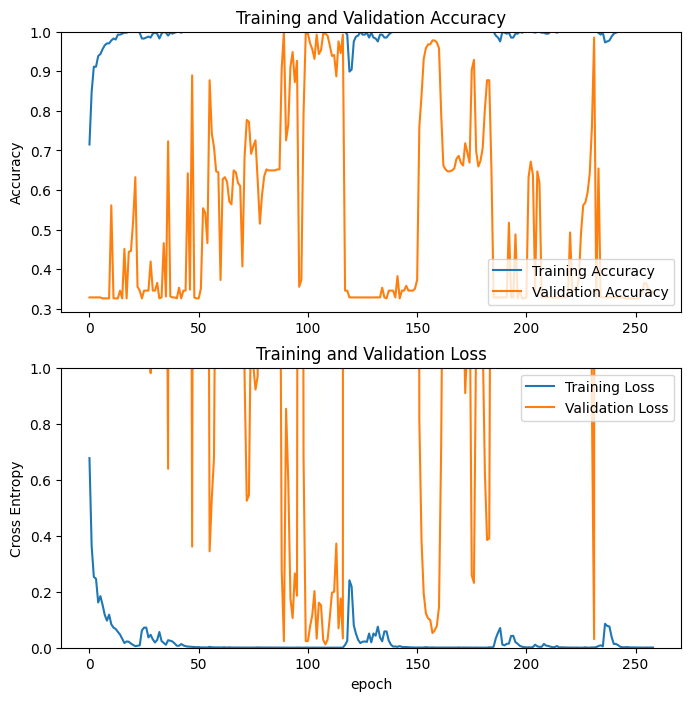

Iteration #2 Training started!
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


INFO:ResNet:#2 || acc=0.968, mean=0.982, stdev=0.0135 || log_loss=0.072, mean=0.042, stdev=0.0299 || epochs=265, mean=261 || time=0:01:58.41
INFO:ResNet:****************************************************************
INFO:ResNet:              precision    recall  f1-score   support

       inner       0.92      0.98      0.95       133
     central       1.00      0.93      0.97       134
       outer       0.99      0.99      0.99       140

   micro avg       0.97      0.97      0.97       407
   macro avg       0.97      0.97      0.97       407
weighted avg       0.97      0.97      0.97       407
 samples avg       0.97      0.97      0.97       407

INFO:ResNet:****************************************************************
INFO:ResNet:****************************************************************
INFO:ResNet:[[0.98 0.   0.01]
 [0.07 0.93 0.  ]
 [0.01 0.   0.99]]
INFO:ResNet:****************************************************************


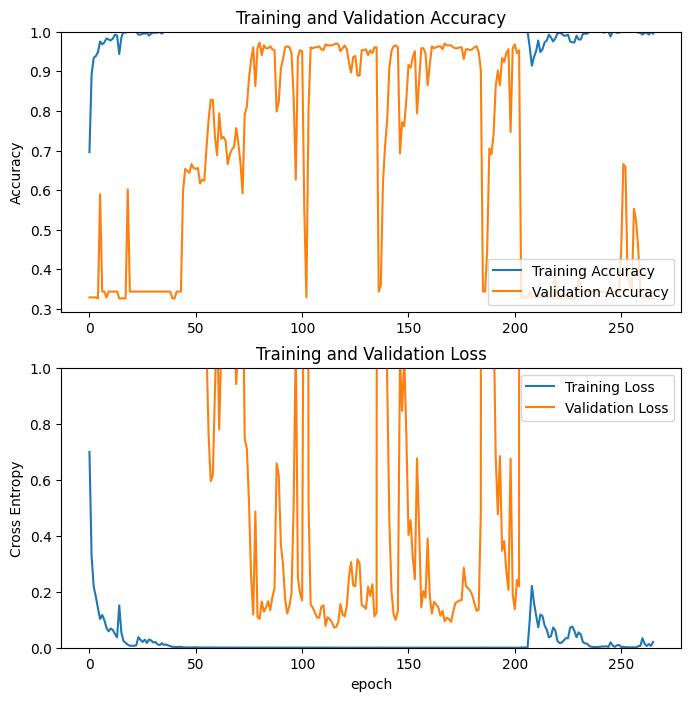

INFO:ResNet:****************************************************************
INFO:ResNet:Finished in 0:04:10.01 - END
INFO:ResNet:****************************************************************


Training finished in 0:04:10.01


In [14]:
 with tf.device('/device:GPU:0'):

    start_time_train = time.time()

    fcn_logger.info("////////////////////////////////////////////////////////////////")
    fcn_logger.info(f"{time.ctime()} - LOG")
    fcn_logger.info("****************************************************************")

    SPLITS = 2
    # StratifiedKFold ensures that the percentages of each class remains the same across all folds
    boot = StratifiedKFold(n_splits=SPLITS, shuffle=True, random_state=40)

    # Track progress
    mean_benchmark = []
    mean_accuracy = []
    epochs_needed = []
    split_idx = 0
    classes = ['inner', 'central', 'outer']

    K.clear_session()

    fcn_logger.info(f"ITERATION:  {split_idx + 1}")

    for train_idx, valid_idx in boot.split(X_data_aug, Y_data_aug.argmax(1)):

      global model
      start_time = time.time()
      split_idx += 1

      # Split train and test
      x_train = X_data_aug[train_idx]
      y_train = Y_data_aug[train_idx]
      x_valid = X_data_aug[valid_idx]
      y_valid = Y_data_aug[valid_idx]

      #get input/output dimensions
      input_shape = x_train.shape[1:]
      nb_classes = y_train.shape[1]

      n_feature_maps = 64

      input_layer = Input(input_shape)

      # BLOCK 1

      conv_x = Conv1D(filters=n_feature_maps, kernel_size=8, padding='same')(input_layer)
      conv_x = BatchNormalization()(conv_x)
      conv_x = Activation('relu')(conv_x)

      conv_y = Conv1D(filters=n_feature_maps, kernel_size=5, padding='same')(conv_x)
      conv_y = BatchNormalization()(conv_y)
      conv_y = Activation('relu')(conv_y)

      conv_z = Conv1D(filters=n_feature_maps, kernel_size=3, padding='same')(conv_y)
      conv_z = BatchNormalization()(conv_z)

      # expand channels for the sum
      shortcut_y = Conv1D(filters=n_feature_maps, kernel_size=1, padding='same')(input_layer)
      shortcut_y = BatchNormalization()(shortcut_y)

      output_block_1 = add([shortcut_y, conv_z])
      output_block_1 = Activation('relu')(output_block_1)

      # BLOCK 2

      conv_x = Conv1D(filters=n_feature_maps * 2, kernel_size=8, padding='same')(output_block_1)
      conv_x = BatchNormalization()(conv_x)
      conv_x = Activation('relu')(conv_x)

      conv_y = Conv1D(filters=n_feature_maps * 2, kernel_size=5, padding='same')(conv_x)
      conv_y = BatchNormalization()(conv_y)
      conv_y = Activation('relu')(conv_y)

      conv_z = Conv1D(filters=n_feature_maps * 2, kernel_size=3, padding='same')(conv_y)
      conv_z = BatchNormalization()(conv_z)

      # expand channels for the sum
      shortcut_y = Conv1D(filters=n_feature_maps * 2, kernel_size=1, padding='same')(output_block_1)
      shortcut_y = BatchNormalization()(shortcut_y)

      output_block_2 = add([shortcut_y, conv_z])
      output_block_2 = Activation('relu')(output_block_2)

      # BLOCK 3

      conv_x = Conv1D(filters=n_feature_maps * 2, kernel_size=8, padding='same')(output_block_2)
      conv_x = BatchNormalization()(conv_x)
      conv_x = Activation('relu')(conv_x)

      conv_y = Conv1D(filters=n_feature_maps * 2, kernel_size=5, padding='same')(conv_x)
      conv_y = BatchNormalization()(conv_y)
      conv_y = Activation('relu')(conv_y)

      conv_z = Conv1D(filters=n_feature_maps * 2, kernel_size=3, padding='same')(conv_y)
      conv_z = BatchNormalization()(conv_z)

      # no need to expand channels because they are equal
      shortcut_y = BatchNormalization()(output_block_2)

      output_block_3 = add([shortcut_y, conv_z])
      output_block_3 = Activation('relu')(output_block_3)

      # FINAL

      gap_layer = GlobalAveragePooling1D()(output_block_3)

      output_layer = Dense(nb_classes, activation='softmax')(gap_layer)

      model = Model(inputs=input_layer, outputs=output_layer)

      model.compile(loss='categorical_crossentropy', optimizer="Adam",
                        metrics=['accuracy'])


      monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3,
                        patience=150, verbose=0, mode='auto',
                        restore_best_weights=True)

      # --------------------------------------------------------------------------

      # Train on the specific fold

      print(f"Iteration #{split_idx} Training started!")

      history = model.fit(x_train, y_train, validation_data=(x_valid, y_valid),
                            callbacks=[monitor], verbose=0, epochs=1000)

      epochs = monitor.stopped_epoch
      epochs_needed.append(epochs)

      # Predict on the validation set
      pred_raw = model.predict(x_valid)

      # get the metrics
      score = metrics.log_loss(y_valid, pred_raw)
      # log loss calculcation must be done before rounding

      # set highest val to 1 others 0
      pred = np.zeros_like(pred_raw)
      pred[np.arange(len(pred_raw)), pred_raw.argmax(1)] = 1

      score_acc = metrics.accuracy_score(y_valid, pred)
      mean_benchmark.append(score)
      mean_accuracy.append(score_acc)
      m1 = statistics.mean(mean_benchmark)
      m2 = statistics.mean(epochs_needed)
      m3 = statistics.mean(mean_accuracy)
      m1dev = statistics.pstdev(mean_benchmark)
      m3dev = statistics.pstdev(mean_accuracy)


      time_took = time.time() - start_time
      fcn_logger.info(f"#{split_idx} || acc={score_acc:.3f}, mean={m3:.3f}, stdev={m3dev:.4f} || "
                      f"log_loss={score:.3f}, mean={m1:.3f}, stdev={m1dev:.4f} || "
                      f"epochs={epochs}, mean={int(m2)} || time={hms_string(time_took)}"
                      )

      class_rep = metrics.classification_report(y_valid, pred, target_names=classes)

      fcn_logger.info("****************************************************************")
      fcn_logger.info(class_rep)
      fcn_logger.info("****************************************************************")




      # Compute confusion matrix
      cm = metrics.confusion_matrix(y_valid.argmax(1), pred.argmax(1))
      np.set_printoptions(precision=2)
      # Normalize the confusion matrix by row (i.e by the number of samples
      # in each class)
      cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

      fcn_logger.info("****************************************************************")
      fcn_logger.info(np.round(cm_normalized,3))
      fcn_logger.info("****************************************************************")

      # save entire network to .keras
      model.save(save_path)

      # Plot fit history
      acc = history.history['accuracy']
      val_acc = history.history['val_accuracy']
      loss = history.history['loss']
      val_loss = history.history['val_loss']

      plt.figure(figsize=(8, 8))
      plt.subplot(2, 1, 1)
      plt.plot(acc, label='Training Accuracy')
      plt.plot(val_acc, label='Validation Accuracy')
      plt.legend(loc='lower right')
      plt.ylabel('Accuracy')
      plt.ylim([min(plt.ylim()),1])
      plt.title('Training and Validation Accuracy')

      plt.subplot(2, 1, 2)
      plt.plot(loss, label='Training Loss')
      plt.plot(val_loss, label='Validation Loss')
      plt.legend(loc='upper right')
      plt.ylabel('Cross Entropy')
      plt.ylim([0,1.0])
      plt.title('Training and Validation Loss')
      plt.xlabel('epoch')
      plt.show()

    total_time_training = time.time() - start_time_train
    print(f"Training finished in {hms_string(total_time_training)}")

    fcn_logger.info("****************************************************************")
    fcn_logger.info(f"Finished in {hms_string(time.time()-start_time_train)} - END")
    fcn_logger.info("****************************************************************")


You can check the log file for how well you have trained, You can also check the cells output. For clarification, see the network structure.

In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 400, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 400, 64)   │      6,208 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 400, 64)   │     20,544 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 400, 64)   │        832 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 400, 64)   │     12,352 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 400, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 400, 64)   │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 400, 128)  │     65,664 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 400, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 400, 128)  │     82,048 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 400, 128)  │          0 │ batch_normalizat

 Total params: 1,534,731 (5.85 MB)

 Trainable params: 510,723 (1.95 MB)

 Non-trainable params: 2,560 (10.00 KB)

 Optimizer params: 1,021,448 (3.90 MB)

## Predict with given model on the test data

In [16]:
model=load_model(save_path)
pred = model.predict(X_data_testing)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


Now lets go for the one with the highest likelyhood

In [17]:
pred_one_hot = np.zeros_like(pred)
pred_one_hot[np.arange(len(pred)), pred.argmax(1)] = 1

In [18]:
accuracy = np.mean(pred_one_hot == Y_data_testing)
print(f"Accuracy: {accuracy}")

Accuracy: 0.978494623655914


Normalized confusion matrix


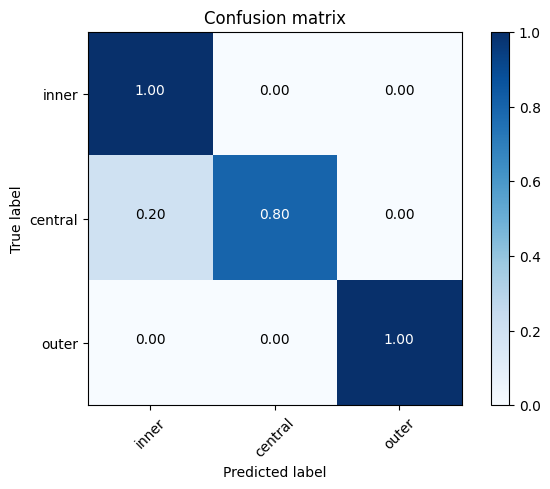

In [19]:
cm = metrics.confusion_matrix(Y_data_testing.argmax(1), pred_one_hot.argmax(1))
classes = ['inner', 'central', 'outer']
plot_confusion_matrix(cm, classes, normalize=True) # Added normalize=True

#### TASK: Repeat it with a variaty of blanked inputs and check how it affecty the accuracy.